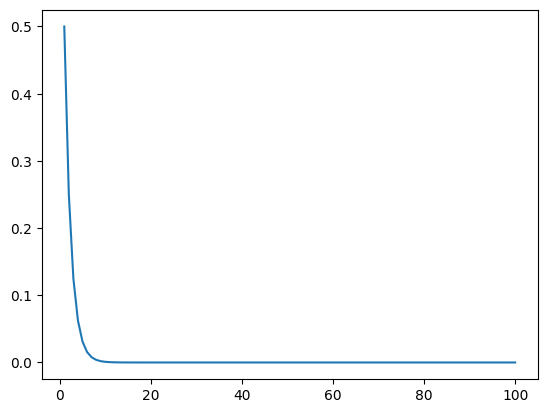

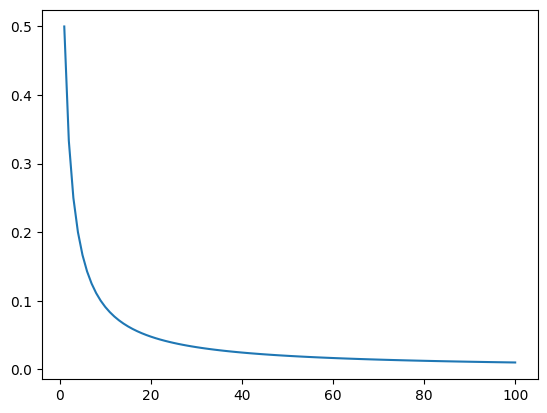

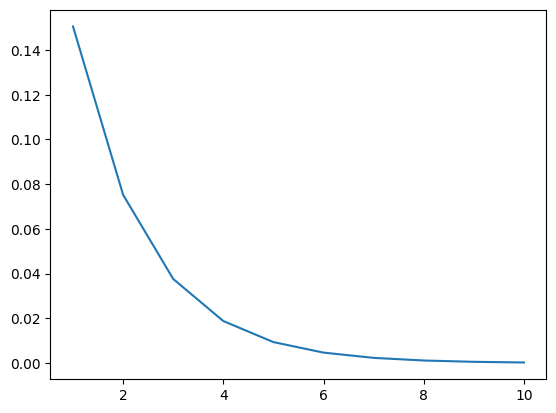

In [2]:
# a) linear convergence
# b) linear convergence
# c) quadratic convergence
import math
import matplotlib.pyplot as plt
from numpy import linspace

def f1(n):
 return 2**-n
def f2(n):
 return (n+1)**(-1)
def logf3(n):
 return 2**(-n)*math.log10(2)

xs_f1 = []
ys_f1 = []

xs_f2 = []
ys_f2 = []

xs_f3 = []
log_ys_f3 = []

for i in range(1,101):
 xs_f1.append(i)
 ys_f1.append(f1(i))

 xs_f2.append(i)
 ys_f2.append(f2(i))

for i in range(1,11):
 xs_f3.append(i)
 log_ys_f3.append(logf3(i))

plt.plot(xs_f1, ys_f1, label = "f1")
plt.show()
plt.plot(xs_f2, ys_f2, label = "f2")
plt.show()
plt.plot(xs_f3, log_ys_f3, label = "f3 with log scale")
plt.show()

4) #yes - sin x is decreasing on the bounded interval so |y-x + sin y - sinx | is going to be less than |y-x| as y-x and siny - sin x will have different sign and sinx - sin y is bounded <1 on the interval
#no - y = 2, x = 1 is clearly a counter example
#no although x^-1 is decreasing as the interval isn't bounded and 1/x - 1/y goes to 0 on the double limit then if we are given a k we can necessarily find a counter example as |x-y + x^-1 - y^-1| -> |x-y|

M = 0.9989797220092432733619926239984748049437570723531522733659490790460192241680822755274234679967074482, q = 0.9999000249944768


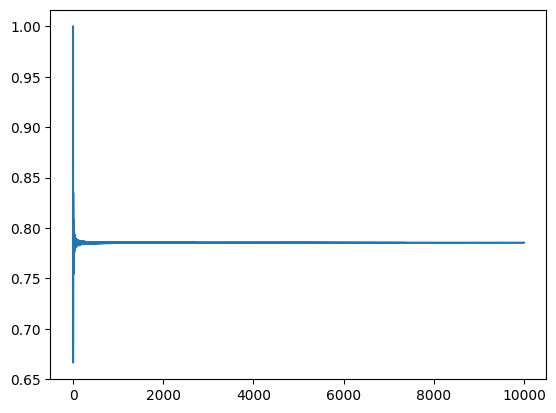

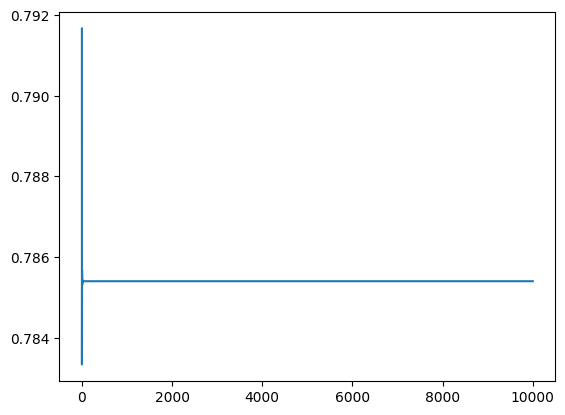

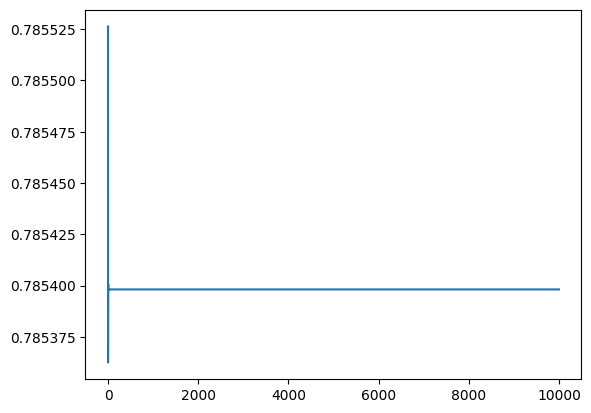

0.9983433449096899
1.0187644664431788


In [3]:
# 5)
# taking the limits given large enough n we can estimate q = log(en+1/en+2)/log(en/en+1) then M = en+2/en+1^q
import sympy as sp
import matplotlib.pyplot as plt
import mpmath as mp
import math

mp.mp.dps = 100
N = sp.Symbol("N")
k = sp.Symbol("k", integer=True, positive=True)
Sum_pi = sp.Function("Sum_pi")

Sum_pi = sp.summation((4*(-1)**(-k))/(2*k +1), (k, 0, N))

def an(n):
    Sum_pi = sp.summation((4*(-1)**(-k))/(2*k +1), (k, 0, n))
    return Sum_pi

def en(n):
    Sum_pi = sp.summation((4*(-1)**(-k))/(2*k +1), (k, 0, n))
    return abs(mp.pi - Sum_pi)
def q(a,b,c):
    temp_q = math.log(b/c) /math.log(a/b)
    return temp_q

def M(a,b,c):
    temp_M = c/(b**q(a,b,c))
    return temp_M

print(f"M = {M(en(10000), en(10001), en(10002))}, q = {q(en(10000), en(10001), en(10002))}")

# M=1 , q = 1
A = []
n = []
A_tilda = []
A_double_tilda = []
def atilda(a,b,c):
    atilda_temp = (a - (b - a)**2 / (c -2*b +a))
    return atilda_temp
a_n = mp.mpf('0')
for i in range(0,10001):
    
    a_n = a_n + mp.mpf((-1)**i) / mp.mpf(2*i + 1)
    a_n_1 = a_n + mp.mpf((-1)**(i+1)) / mp.mpf(2*i + 3)
    a_n_2 = a_n_1 + mp.mpf((-1)**(i+2)) / mp.mpf(2*i + 5)
    a_n_3 = a_n_2 + mp.mpf((-1)**(i+3)) / mp.mpf(2*i + 7)
    a_n_4 = a_n_3 + mp.mpf((-1)**(i+4)) / mp.mpf(2*i + 9)

    a_tilda = atilda(a_n, a_n_1, a_n_2)
    a_tilda_1 = atilda(a_n_1, a_n_2, a_n_3)
    a_tilda_2 = atilda(a_n_2, a_n_3, a_n_4)

    a_double_tilda = atilda(a_tilda, a_tilda_1, a_tilda_2)

    n.append(i)
    A.append(a_n)
    A_tilda.append(a_tilda)
    A_double_tilda.append(a_double_tilda)


plt.plot(n, A, label = "an")
plt.show()
plt.plot(n, A_tilda, label = "A tilda")
plt.show()
plt.plot(n, A_double_tilda, label = "A double tilda")
plt.show()

print(q(abs(A_tilda[1000]-math.pi/4),abs(A_tilda[1001]-math.pi/4),abs(A_tilda[1002]-math.pi/4)))
print(abs(q(abs(A_double_tilda[1001]-math.pi/4),abs(A_double_tilda[1002]-math.pi/4),abs(A_double_tilda[1003]-math.pi/4))))